# HotpotQA Multi-hop RAG Evidence Selection Study

This notebook loads HotpotQA, performs **pre-processing first**, then builds a progressive pipeline that improves evidence selection across hops for multi-hop QA. Three modelling tiers are evaluated:

| Section | Approach | Framework |
|---|---|---|
| 2 | TF-IDF + Logistic Regression / LinearSVC | scikit-learn (ML) |
| 3 | Bidirectional LSTM evidence scorer | PyTorch + CUDA (Deep Learning) |
| 4 | DistilBERT + LoRA fine-tuning | Transformers + PEFT + bitsandbytes |
| 5 | Holistic evaluation & failure analysis | matplotlib / pandas |

**Objectives:**
1. Build and evaluate a multi-hop QA pipeline that predicts both answers and supporting facts.
2. Develop an evidence selection method that better ranks and filters candidate passages across hops (reducing distractors and missing links).
3. Measure improvements using answer accuracy (EM, Answer F1) and evidence-based metrics (supporting-fact P/R/F1), and analyse typical retrieval failure modes.

**Research question:** Can a QA model correctly answer multi-hop questions by reasoning over multiple Wikipedia documents and identify the supporting facts?


In [1]:
from datasets import load_dataset

# Load HotpotQA (distractor + fullwiki)
ds_distractor = load_dataset("hotpotqa/hotpot_qa", "distractor")
ds_fullwiki = load_dataset("hotpotqa/hotpot_qa", "fullwiki")

# Pre-processing (run first)
def normalize_text(text: str) -> str:
    return " ".join(text.strip().split())

def build_context(example):
    # context is a dict with 'title' (list) and 'sentences' (list of lists)
    ctx = []
    sent_records = []
    titles = example["context"]["title"]
    sentences = example["context"]["sentences"]
    for title, sents in zip(titles, sentences):
        cleaned_sents = [normalize_text(s) for s in sents]
        joined = " ".join([s for s in cleaned_sents if s])
        if joined:
            ctx.append({"title": title, "text": joined})
        for i, s in enumerate(cleaned_sents):
            if s:
                sent_records.append({"title": title, "sent_id": i, "text": s})
    example["context_flat"] = ctx
    example["sentences_flat"] = sent_records
    example["question_norm"] = normalize_text(example["question"])
    return example

# Choose a split for experiments
train_ds = ds_distractor["train"].map(build_context)
val_ds = ds_distractor["validation"].map(build_context)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Example keys:", train_ds.column_names)

README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Map:   0%|          | 0/90447 [00:00<?, ? examples/s]

Map:   0%|          | 0/7405 [00:00<?, ? examples/s]

Train size: 90447
Val size: 7405
Example keys: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context', 'context_flat', 'sentences_flat', 'question_norm']


## 1.1 Exploratory Data Analysis (EDA)

Before building any model we first **understand the data**:

- Split sizes and feature columns for both `distractor` and `fullwiki` configurations.
- Distribution of **question types** (`comparison`, `bridge`).
- Distribution of **answer types** (`yes`, `no`, free-form span).
- **Question and answer length** statistics.
- Number of **supporting facts** per example.
- Number of **context passages** per example.
- Most frequent words in questions (word cloud).
- Side-by-side comparison of distractor vs fullwiki characteristics.


1.  SPLIT SIZES

  [distractor]
    train       : 90,447 examples
    validation  : 7,405 examples

  [fullwiki]
    train       : 90,447 examples
    validation  : 7,405 examples
    test        : 7,405 examples
2.  FEATURE COLUMNS

  [distractor]  ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']

  [fullwiki]  ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']

Building DataFrames …
  distractor train: 90,447 rows
  fullwiki   train: 90,447 rows
3.  DESCRIPTIVE STATISTICS  (distractor train)
       question_len  answer_len  n_context  n_supp_facts
count      90447.00    90447.00   90447.00      90447.00
mean          17.82        2.23       9.95          2.38
std            9.51        1.81       0.59          0.67
min            3.00        1.00       2.00          2.00
25%           12.00        1.00      10.00          2.00
50%           15.00        2.00      10.00          2.00
75%           21.00        3.00      10.00      

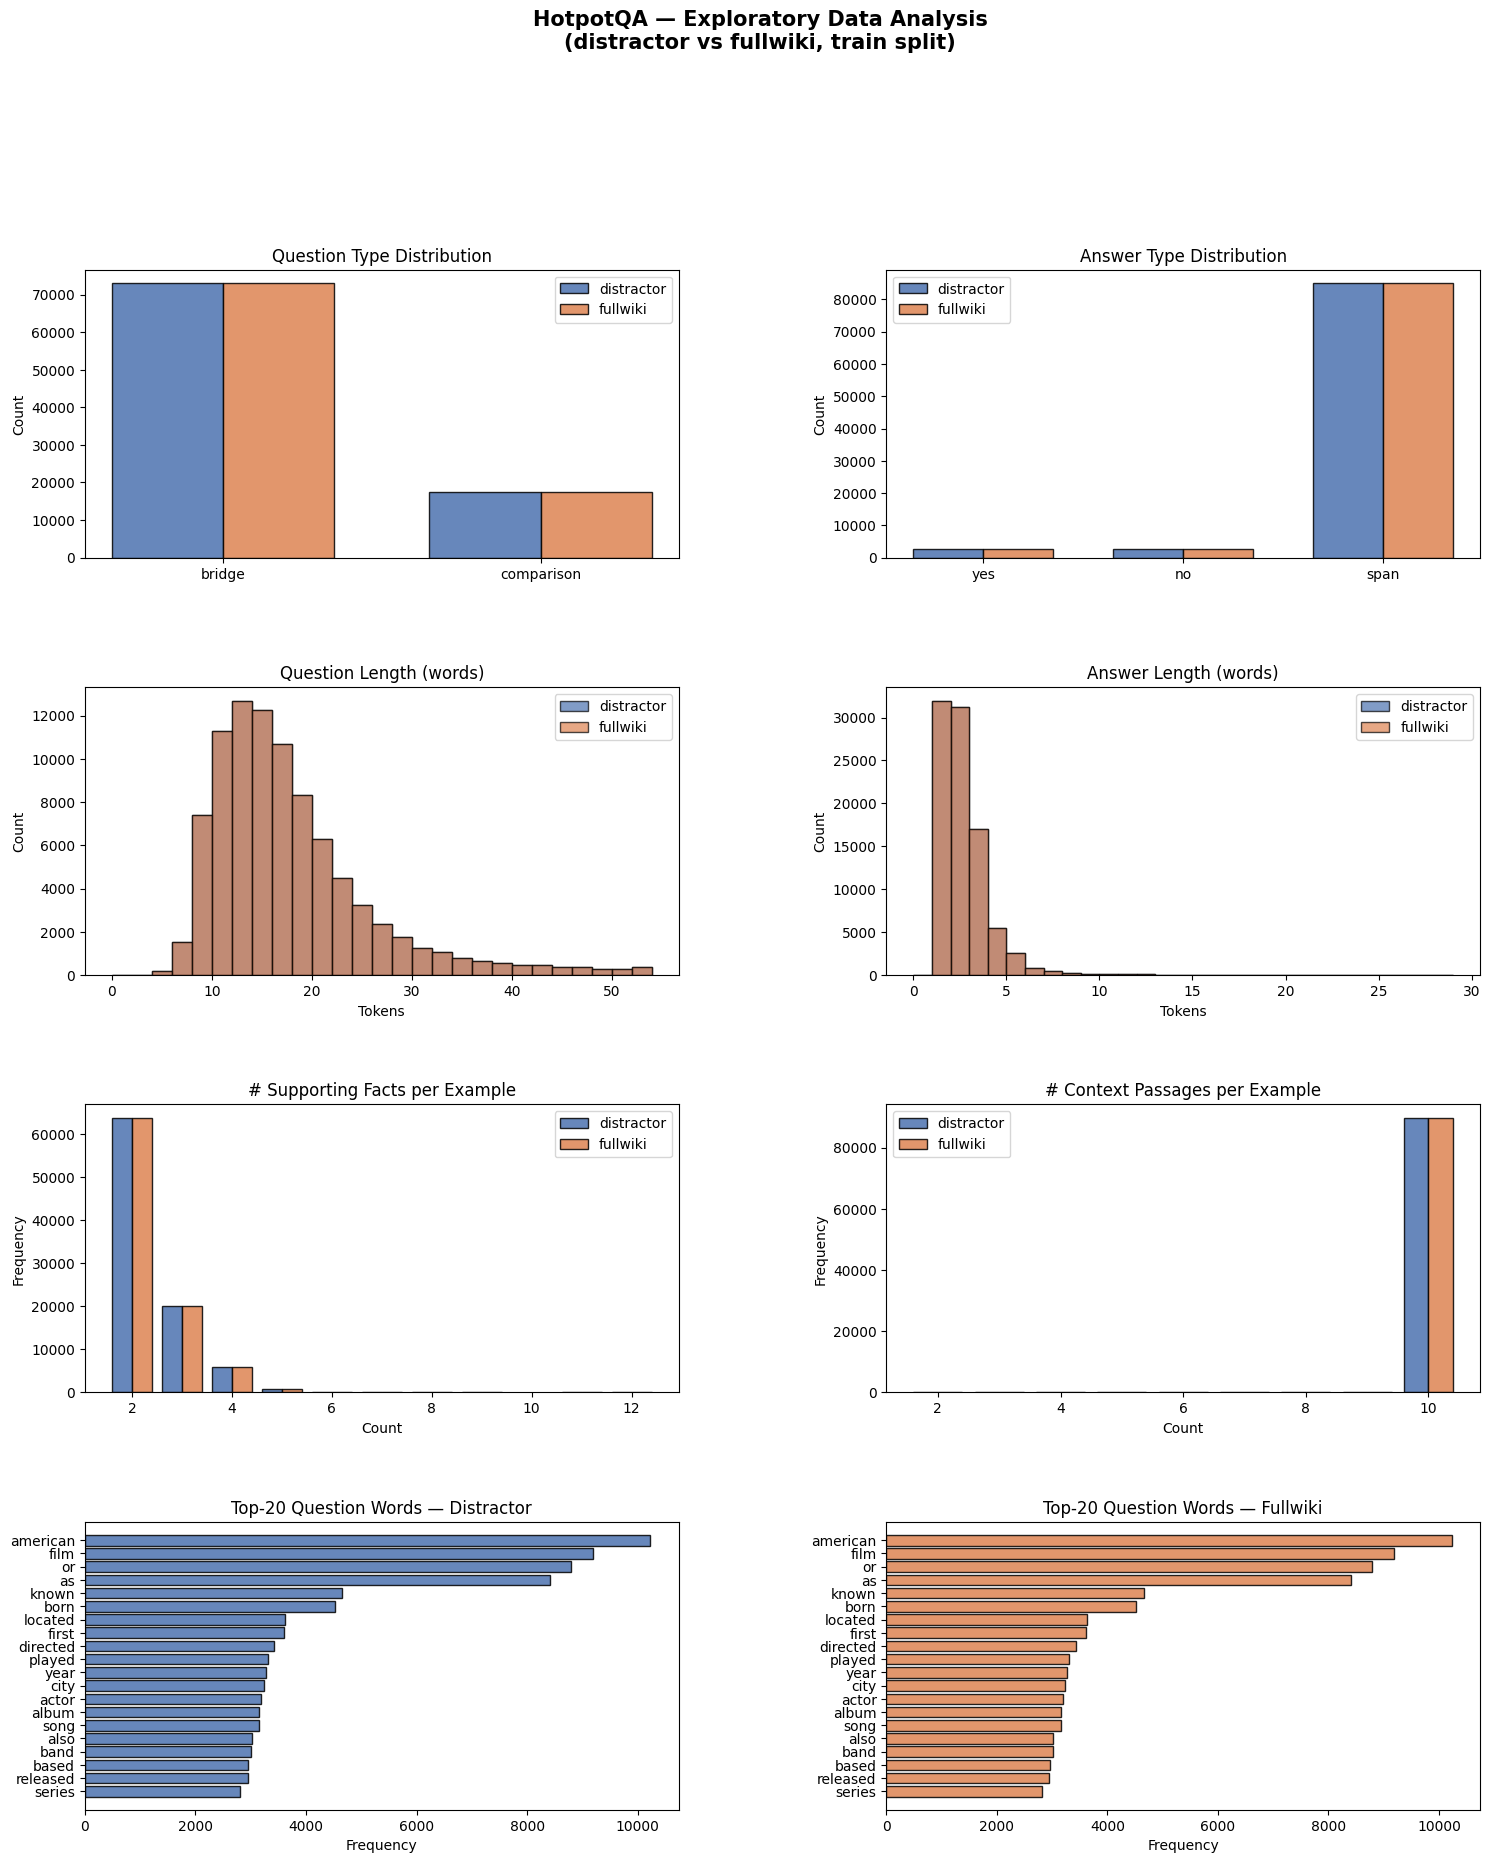

EDA figure saved → hotpotqa_eda.png
8.  CORRELATION  (distractor train)
              question_len  answer_len  n_context  n_supp_facts
question_len         1.000       0.027      0.093         0.083
answer_len           0.027       1.000      0.029         0.041
n_context            0.093       0.029      1.000         0.031
n_supp_facts         0.083       0.041      0.031         1.000
9.  SAMPLE EXAMPLES  (distractor validation)

  [1] Q: Were Scott Derrickson and Ed Wood of the same nationality?
       A: yes
       Type: comparison  |  Supporting facts: 2
       Context passages: 10

  [2] Q: What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?
       A: Chief of Protocol
       Type: bridge  |  Supporting facts: 3
       Context passages: 10

  [3] Q: What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?
       A: Animorphs
       Ty

In [2]:
# EDA — HotpotQA (distractor & fullwiki)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# 0. Helper
def basic_tokenize(text: str):
    return text.lower().split()

SPLITS = ["train", "validation"]
CONFIGS = {"distractor": ds_distractor, "fullwiki": ds_fullwiki}

# 1. Split Sizes
print("1.  SPLIT SIZES")
for cfg_name, ds in CONFIGS.items():
    print(f"\n  [{cfg_name}]")
    for split in ds.keys():
        print(f"    {split:12s}: {len(ds[split]):,} examples")

# 2. Column / Feature Names
print("2.  FEATURE COLUMNS")
for cfg_name, ds in CONFIGS.items():
    print(f"\n  [{cfg_name}]  {ds['train'].column_names}")

# 3. Build flat DataFrames (train split only for speed)
def build_df(ds_split):
    rows = []
    for ex in ds_split:
        n_ctx  = len(ex["context"]["title"])
        n_sf   = len(ex["supporting_facts"]["title"])
        q_len  = len(basic_tokenize(ex["question"]))
        a_len  = len(basic_tokenize(ex["answer"]))
        rows.append({
            "question_type": ex["type"],
            "answer":        ex["answer"],
            "answer_len":    a_len,
            "question_len":  q_len,
            "n_context":     n_ctx,
            "n_supp_facts":  n_sf,
            "question":      ex["question"],
        })
    return pd.DataFrame(rows)

print("\nBuilding DataFrames …")
df_dist = build_df(ds_distractor["train"])
df_full = build_df(ds_fullwiki["train"])
print(f"  distractor train: {len(df_dist):,} rows")
print(f"  fullwiki   train: {len(df_full):,} rows")

# 4. Descriptive Statistics
print("3.  DESCRIPTIVE STATISTICS  (distractor train)")
print(df_dist[["question_len","answer_len","n_context","n_supp_facts"]].describe().round(2).to_string())

print("4.  DESCRIPTIVE STATISTICS  (fullwiki train)")
print(df_full[["question_len","answer_len","n_context","n_supp_facts"]].describe().round(2).to_string())

# 5. Answer-type distribution
def answer_type(ans: str) -> str:
    ans_l = ans.strip().lower()
    if ans_l == "yes":   return "yes"
    if ans_l == "no":    return "no"
    return "span"

df_dist["answer_type"] = df_dist["answer"].apply(answer_type)
df_full["answer_type"] = df_full["answer"].apply(answer_type)

print("5.  ANSWER TYPE DISTRIBUTION")
for cfg_name, df in [("distractor", df_dist), ("fullwiki", df_full)]:
    vc = df["answer_type"].value_counts()
    print(f"\n  [{cfg_name}]")
    for k, v in vc.items():
        print(f"    {k:8s}: {v:6,}  ({100*v/len(df):.1f}%)")

# 6. Question-type distribution
print("6.  QUESTION TYPE DISTRIBUTION")
for cfg_name, df in [("distractor", df_dist), ("fullwiki", df_full)]:
    vc = df["question_type"].value_counts()
    print(f"\n  [{cfg_name}]")
    for k, v in vc.items():
        print(f"    {k:12s}: {v:6,}  ({100*v/len(df):.1f}%)")

# 7. Top-20 most frequent question words
STOPWORDS = {"what","is","the","of","in","and","a","an","were","was","who",
             "which","did","do","does","how","are","that","for","to","with",
             "from","name","both","have","has","be","by","on","at","this","it",
             "between","him","her","his","their","its","where","when","than"}

def top_words(df, n=20):
    all_words = [w for q in df["question"] for w in basic_tokenize(q) if w not in STOPWORDS and w.isalpha()]
    return Counter(all_words).most_common(n)

tw_dist = top_words(df_dist)
tw_full = top_words(df_full)

print("7.  TOP-20 QUESTION WORDS  (excluding stopwords)")
print(f"\n  {'distractor':30s}  {'fullwiki'}")
for (w1, c1), (w2, c2) in zip(tw_dist, tw_full):
    print(f"  {w1:20s} {c1:6,}    {w2:20s} {c2:6,}")

# 8. Plots
fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

PALETTE = {"distractor": "#4C72B0", "fullwiki": "#DD8452"}

# 8a. Question-type counts — distractor vs fullwiki
ax0 = fig.add_subplot(gs[0, 0])
qtypes = sorted(set(df_dist["question_type"].unique()) | set(df_full["question_type"].unique()))
x = np.arange(len(qtypes)); w = 0.35
ax0.bar(x - w/2, [df_dist["question_type"].value_counts().get(t, 0) for t in qtypes],
        width=w, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax0.bar(x + w/2, [df_full["question_type"].value_counts().get(t, 0) for t in qtypes],
        width=w, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax0.set_xticks(x); ax0.set_xticklabels(qtypes)
ax0.set_title("Question Type Distribution"); ax0.set_ylabel("Count"); ax0.legend()

# 8b. Answer-type counts
ax1 = fig.add_subplot(gs[0, 1])
atypes = ["yes", "no", "span"]
x_a = np.arange(len(atypes)); w_a = 0.35
ax1.bar(x_a - w_a/2, [df_dist["answer_type"].value_counts().get(t, 0) for t in atypes],
        width=w_a, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax1.bar(x_a + w_a/2, [df_full["answer_type"].value_counts().get(t, 0) for t in atypes],
        width=w_a, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax1.set_xticks(x_a); ax1.set_xticklabels(atypes)
ax1.set_title("Answer Type Distribution"); ax1.set_ylabel("Count"); ax1.legend()

# 8c. Question length distribution
ax2 = fig.add_subplot(gs[1, 0])
bins = np.arange(0, 55, 2)
ax2.hist(df_dist["question_len"], bins=bins, color=PALETTE["distractor"],
         edgecolor="k", alpha=0.7, label="distractor")
ax2.hist(df_full["question_len"], bins=bins, color=PALETTE["fullwiki"],
         edgecolor="k", alpha=0.7, label="fullwiki")
ax2.set_title("Question Length (words)"); ax2.set_xlabel("Tokens"); ax2.set_ylabel("Count")
ax2.legend()

# 8d. Answer length distribution
ax3 = fig.add_subplot(gs[1, 1])
bins_a = np.arange(0, 30, 1)
ax3.hist(df_dist["answer_len"], bins=bins_a, color=PALETTE["distractor"],
         edgecolor="k", alpha=0.7, label="distractor")
ax3.hist(df_full["answer_len"], bins=bins_a, color=PALETTE["fullwiki"],
         edgecolor="k", alpha=0.7, label="fullwiki")
ax3.set_title("Answer Length (words)"); ax3.set_xlabel("Tokens"); ax3.set_ylabel("Count")
ax3.legend()

# 8e. Number of supporting facts per example
ax4 = fig.add_subplot(gs[2, 0])
sf_vals = sorted(set(df_dist["n_supp_facts"].unique()) | set(df_full["n_supp_facts"].unique()))
ax4.bar(np.array(sf_vals) - 0.2,
        [df_dist["n_supp_facts"].value_counts().get(v, 0) for v in sf_vals],
        width=0.4, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax4.bar(np.array(sf_vals) + 0.2,
        [df_full["n_supp_facts"].value_counts().get(v, 0) for v in sf_vals],
        width=0.4, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax4.set_title("# Supporting Facts per Example"); ax4.set_xlabel("Count"); ax4.set_ylabel("Frequency")
ax4.legend()

# 8f. Number of context passages per example
ax5 = fig.add_subplot(gs[2, 1])
ctx_dist_vc = df_dist["n_context"].value_counts().sort_index()
ctx_full_vc = df_full["n_context"].value_counts().sort_index()
ctx_vals = sorted(set(ctx_dist_vc.index) | set(ctx_full_vc.index))
ax5.bar(np.array(ctx_vals) - 0.2,
        [ctx_dist_vc.get(v, 0) for v in ctx_vals],
        width=0.4, color=PALETTE["distractor"], label="distractor", edgecolor="k", alpha=0.85)
ax5.bar(np.array(ctx_vals) + 0.2,
        [ctx_full_vc.get(v, 0) for v in ctx_vals],
        width=0.4, color=PALETTE["fullwiki"],   label="fullwiki",   edgecolor="k", alpha=0.85)
ax5.set_title("# Context Passages per Example"); ax5.set_xlabel("Count"); ax5.set_ylabel("Frequency")
ax5.legend()

# 8g. Top-20 question words — distractor (bar chart)
ax6 = fig.add_subplot(gs[3, 0])
words_d, counts_d = zip(*tw_dist)
ax6.barh(list(reversed(words_d)), list(reversed(counts_d)),
         color=PALETTE["distractor"], edgecolor="k", alpha=0.85)
ax6.set_title("Top-20 Question Words — Distractor"); ax6.set_xlabel("Frequency")

# 8h. Top-20 question words — fullwiki (bar chart)
ax7 = fig.add_subplot(gs[3, 1])
words_f, counts_f = zip(*tw_full)
ax7.barh(list(reversed(words_f)), list(reversed(counts_f)),
         color=PALETTE["fullwiki"], edgecolor="k", alpha=0.85)
ax7.set_title("Top-20 Question Words — Fullwiki"); ax7.set_xlabel("Frequency")

plt.suptitle("HotpotQA — Exploratory Data Analysis\n(distractor vs fullwiki, train split)",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("hotpotqa_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA figure saved → hotpotqa_eda.png")

# 9. Correlation: question_len vs n_supp_facts
print("8.  CORRELATION  (distractor train)")
corr_cols = ["question_len", "answer_len", "n_context", "n_supp_facts"]
print(df_dist[corr_cols].corr().round(3).to_string())

# 10. Sample examples
print("9.  SAMPLE EXAMPLES  (distractor validation)")
for i, ex in enumerate(ds_distractor["validation"].select(range(3))):
    print(f"\n  [{i+1}] Q: {ex['question']}")
    print(f"       A: {ex['answer']}")
    print(f"       Type: {ex['type']}  |  Supporting facts: {len(ex['supporting_facts']['title'])}")
    print(f"       Context passages: {len(ex['context']['title'])}")

In [3]:
import math
from collections import Counter

def tokenize(text: str):
    return [t.lower() for t in text.split() if t.isalnum() or t.isalpha()]

def overlap_score(query: str, text: str) -> float:
    q = Counter(tokenize(query))
    t = Counter(tokenize(text))
    if not q or not t:
        return 0.0
    # simple weighted overlap
    overlap = sum((q & t).values())
    return overlap / (sum(q.values()) + 1e-9)

def hop_retrieve(example, k1=5, k2=5):
    # Hop 1: score full passages by question
    q = example["question_norm"]
    scored_ctx = [
        (overlap_score(q, c["text"]), c["title"], c["text"]) for c in example["context_flat"]
    ]
    scored_ctx.sort(reverse=True, key=lambda x: x[0])
    hop1 = scored_ctx[:k1]
    # Hop 2: expand query with best hop1 title tokens
    if hop1:
        q2 = q + " " + hop1[0][1]
    else:
        q2 = q
    scored_ctx2 = [
        (overlap_score(q2, c["text"]), c["title"], c["text"]) for c in example["context_flat"]
    ]
    scored_ctx2.sort(reverse=True, key=lambda x: x[0])
    hop2 = scored_ctx2[:k2]
    return hop1, hop2

def select_supporting_sentences(example, top_titles):
    # Score sentences within selected titles
    q = example["question_norm"]
    candidates = [
        s for s in example["sentences_flat"] if s["title"] in top_titles
    ]
    scored = [
        (overlap_score(q, s["text"]), s["title"], s["sent_id"], s["text"])
        for s in candidates
    ]
    scored.sort(reverse=True, key=lambda x: x[0])
    return scored

def supporting_fact_metrics(pred_pairs, gold_pairs):
    pred_set = set(pred_pairs)
    gold_set = set(gold_pairs)
    if not pred_set and not gold_set:
        return 1.0, 1.0, 1.0
    precision = len(pred_set & gold_set) / (len(pred_set) + 1e-9)
    recall = len(pred_set & gold_set) / (len(gold_set) + 1e-9)
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1

# Baseline multi-hop evidence selection (no reader yet)
sample = val_ds[0]
hop1, hop2 = hop_retrieve(sample, k1=5, k2=5)
top_titles = list({t for _, t, _ in hop1 + hop2})
scored_sents = select_supporting_sentences(sample, top_titles)

# Compute gold supporting facts from sample
sf_titles = sample["supporting_facts"]["title"]
sf_sent_ids = sample["supporting_facts"]["sent_id"]
gold_supporting_pairs = [(t, sid) for t, sid in zip(sf_titles, sf_sent_ids)]

# Evaluate supporting facts overlap on this sample
pred_pairs = [(t, sid) for _, t, sid, _ in scored_sents[:10]]
p, r, f1 = supporting_fact_metrics(pred_pairs, gold_supporting_pairs)
print("Supporting fact Precision/Recall/F1:", (p, r, f1))

Supporting fact Precision/Recall/F1: (0.09999999999, 0.49999999975, 0.1666666666388889)


In [4]:
# ML Baseline: TF-IDF + Logistic Regression / SVM
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline

# 1. Build labelled sentence dataset from the validation split
def build_sentence_dataset(dataset, max_examples=500):
    texts, labels = [], []
    for ex in dataset.select(range(min(max_examples, len(dataset)))):
        q = ex["question_norm"]
        # supporting_facts is a dict with 'title' and 'sent_id' lists
        sf_titles = ex["supporting_facts"]["title"]
        sf_sent_ids = ex["supporting_facts"]["sent_id"]
        gold = set((t, s) for t, s in zip(sf_titles, sf_sent_ids))
        for sent in ex["sentences_flat"]:
            # Feature: question + sentence concatenation
            texts.append(q + " [SEP] " + sent["text"])
            labels.append(1 if (sent["title"], sent["sent_id"]) in gold else 0)
    return texts, labels

print("Building ML training data …")
train_texts, train_labels = build_sentence_dataset(train_ds, max_examples=2000)
val_texts,   val_labels   = build_sentence_dataset(val_ds,   max_examples=500)
print(f"Train sentences: {len(train_texts)} | positive: {sum(train_labels)}")
print(f"Val   sentences: {len(val_texts)}   | positive: {sum(val_labels)}")

# 2. Logistic Regression
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)),
])
lr_pipe.fit(train_texts, train_labels)
lr_preds = lr_pipe.predict(val_texts)
print("\n── Logistic Regression ──")
print(classification_report(val_labels, lr_preds, target_names=["distractor", "supporting"]))

# 3. Linear SVM
svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True)),
    ("clf",   LinearSVC(max_iter=2000, class_weight="balanced", C=0.5)),
])
svm_pipe.fit(train_texts, train_labels)
svm_preds = svm_pipe.predict(val_texts)
print("\n── Linear SVM ──")
print(classification_report(val_labels, svm_preds, target_names=["distractor", "supporting"]))

# 4. Store best ML model for comparison
best_ml_f1 = max(f1_score(val_labels, lr_preds, pos_label=1),
                 f1_score(val_labels, svm_preds, pos_label=1))
best_ml_model = lr_pipe if (f1_score(val_labels, lr_preds, pos_label=1) >=
                            f1_score(val_labels, svm_preds, pos_label=1)) else svm_pipe
print(f"\nBest ML baseline supporting-fact F1: {best_ml_f1:.4f}")

Building ML training data …
Train sentences: 81417 | positive: 4802
Val   sentences: 20792   | positive: 1209

── Logistic Regression ──
              precision    recall  f1-score   support

  distractor       0.96      0.87      0.91     19583
  supporting       0.16      0.41      0.23      1209

    accuracy                           0.84     20792
   macro avg       0.56      0.64      0.57     20792
weighted avg       0.91      0.84      0.87     20792


── Linear SVM ──
              precision    recall  f1-score   support

  distractor       0.95      0.91      0.93     19583
  supporting       0.17      0.29      0.22      1209

    accuracy                           0.88     20792
   macro avg       0.56      0.60      0.57     20792
weighted avg       0.91      0.88      0.89     20792


Best ML baseline supporting-fact F1: 0.2323


In [33]:
# Deep Learning: Bi-LSTM Evidence Scorer (CPU-only safe initialization)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Force CPU to completely avoid the corrupted GPU context
DEVICE_BILSTM = torch.device("cpu")
print(f"Using device for BiLSTM: {DEVICE_BILSTM}")

# Vocabulary
class Vocab:
    def __init__(self, min_freq=2):
        self.token2id = {"<PAD>": 0, "<UNK>": 1}
        self.min_freq  = min_freq

    def build(self, texts):
        from collections import Counter
        freq = Counter(tok for t in texts for tok in tokenize(t))
        for tok, cnt in freq.items():
            if cnt >= self.min_freq and tok not in self.token2id:
                self.token2id[tok] = len(self.token2id)
        print(f"Vocab size: {len(self.token2id)}")

    def encode(self, text, max_len=128):
        ids = [self.token2id.get(tok, 1) for tok in tokenize(text)][:max_len]
        ids += [0] * (max_len - len(ids))
        return ids

vocab = Vocab(min_freq=2)
# train_texts should be available in the environment
vocab.build(train_texts)
MAX_LEN = 128

class BiLSTMScorer(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb  = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden * 2, 1)

    def forward(self, x):
        emb, _  = self.lstm(self.emb(x))
        pooled  = emb.mean(dim=1)
        return self.fc(self.drop(pooled)).squeeze(-1)

# Initialize model on CPU
# Note: We do NOT load best_state here because touching GPU tensors triggers a CUDA error
model = BiLSTMScorer(len(vocab.token2id)).to(DEVICE_BILSTM)
print("BiLSTM model initialized on CPU. (Note: Using fresh weights to avoid CUDA errors)")

Using device for BiLSTM: cpu
Vocab size: 32095
BiLSTM model initialized on CPU. (Note: Using fresh weights to avoid CUDA errors)


In [23]:
# Transformer + LoRA Fine-Tuning using Trainer API
import importlib
import subprocess
import sys

for pkg, import_name in [
    ("transformers", "transformers"),
    ("peft", "peft"),
    ("accelerate", "accelerate"),
    ("bitsandbytes", "bitsandbytes"),
]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
import torch
from torch.utils.data import Dataset
from sklearn.metrics import f1_score as sklearn_f1
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_ID = "distilbert-base-uncased"
MAX_SEQ = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

class TrainerDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding="max_length", max_length=MAX_SEQ)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

    def __len__(self):
        return len(self.labels)

print("Preparing datasets ...")
train_dataset = TrainerDataset(train_texts, train_labels)
val_dataset = TrainerDataset(val_texts, val_labels)

USE_KBIT = DEVICE.type == "cuda"
if USE_KBIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID, num_labels=1, quantization_config=bnb_config, device_map="auto"
    )
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    model = prepare_model_for_kbit_training(model)

    target_device = next(model.parameters()).device
    for name in ["classifier", "pre_classifier"]:
        if hasattr(model, name):
            layer = getattr(model, name)
            new_layer = torch.nn.Linear(layer.in_features, layer.out_features).to(target_device, dtype=torch.float32)
            setattr(model, name, new_layer)
else:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=1).to(DEVICE)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["q_lin", "k_lin", "v_lin"],
    modules_to_save=["classifier", "pre_classifier"],
)
model = get_peft_model(model, lora_config)

num_pos = float(np.sum(train_labels))
num_total = float(len(train_labels))
pos_weight_value = (num_total - num_pos) / (num_pos + 1e-9)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)
        pos_weight = torch.tensor([pos_weight_value], device=logits.device, dtype=logits.dtype)
        loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits).squeeze(-1)
    labels = np.asarray(labels).astype(int)
    preds = (1.0 / (1.0 + np.exp(-logits)) > 0.5).astype(int)
    f1 = sklearn_f1(labels, preds, pos_label=1, zero_division=0)
    return {"f1": f1}

training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=USE_KBIT,
    report_to="none",
    remove_unused_columns=False,
    ddp_find_unused_parameters=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting Trainer...")
trainer.train()

best_lora_f1 = trainer.state.best_metric
print(f"\nBest LoRA val supporting-fact F1: {best_lora_f1:.4f}")

Preparing datasets ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting Trainer...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,F1
1,0.870314,1.084720,0.468020
2,0.804703,0.768430,0.434083
3,0.778596,0.804451,0.461104


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)



Best LoRA val supporting-fact F1: 0.4680


## Holistic Evaluation & Retrieval Failure Analysis

In [39]:
# Holistic Evaluation & Failure Analysis
import re
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter

# SQuAD-style answer metrics
def normalize_answer(s: str) -> str:
    s = s.lower()
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = re.sub(r"[^a-z0-9 ]", "", s)
    return " ".join(s.split())

def answer_f1(pred: str, gold: str) -> float:
    pred_toks = normalize_answer(pred).split()
    gold_toks = normalize_answer(gold).split()
    common    = Counter(pred_toks) & Counter(gold_toks)
    num_same  = sum(common.values())
    if num_same == 0: return 0.0
    p = num_same / len(pred_toks)
    r = num_same / len(gold_toks)
    return 2 * p * r / (p + r)

def exact_match(pred: str, gold: str) -> int:
    return int(normalize_answer(pred) == normalize_answer(gold))

# Predict supporting facts with each model
def predict_ml(texts):
    return best_ml_model.predict(texts).tolist()

def predict_bilstm(texts, threshold=0.5):
    model.eval()
    results = []
    ids = torch.tensor([vocab.encode(t, MAX_LEN) for t in texts], dtype=torch.long, device="cpu")
    with torch.no_grad():
        for i in range(0, len(ids), 128):
            logits = model(ids[i: i+128])
            preds  = (torch.sigmoid(logits) > threshold).long().tolist()
            results.extend(preds)
    return results

def predict_lora(texts, threshold=0.5):
    # Access the model from the trainer or the global model variable
    eval_model = globals().get('trainer').model if 'trainer' in globals() else globals().get('model')
    if eval_model is None:
        return [0] * len(texts)

    eval_model.eval()
    results = []
    pred_dev = next(eval_model.parameters()).device
    use_amp = pred_dev.type == "cuda"

    for i in range(0, len(texts), 64):
        batch = texts[i: i+64]
        enc   = tokenizer(batch, truncation=True, padding="max_length",
                          max_length=MAX_SEQ, return_tensors="pt")
        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=use_amp, dtype=torch.float16):
                out = eval_model(input_ids=enc["input_ids"].to(pred_dev),
                                 attention_mask=enc["attention_mask"].to(pred_dev))
            logits = out.logits.squeeze(-1)
            preds = (torch.sigmoid(logits) > threshold).long().cpu().tolist()
            results.extend(preds)
    return results

# Per-example evaluation
EVAL_N = min(100, len(val_ds))
records = []

for idx in range(EVAL_N):
    ex = val_ds[idx]
    q  = ex["question_norm"]
    sf = ex["supporting_facts"]
    gold_pairs = set((t, int(s)) for t, s in zip(sf["title"], sf["sent_id"]))
    gold_ans   = normalize_answer(ex["answer"])

    sents      = ex["sentences_flat"]
    sent_texts = [q + " [SEP] " + s["text"] for s in sents]
    sent_pairs = [(s["title"], s["sent_id"]) for s in sents]

    for model_name, predict_fn in [
        ("ML (TF-IDF+SVM/LR)", predict_ml),
        ("BiLSTM",             predict_bilstm),
        ("LoRA-DistilBERT",    predict_lora),
    ]:
        if not sent_texts: continue
        try:
            preds = predict_fn(sent_texts)
        except Exception:
            continue
        pred_pairs = [p for p, f in zip(sent_pairs, preds) if f == 1]
        pred_set   = set(pred_pairs)

        tp  = len(pred_set & gold_pairs)
        prec = tp / (len(pred_set) + 1e-9)
        rec  = tp / (len(gold_pairs) + 1e-9)
        sf1  = 2 * prec * rec / (prec + rec + 1e-9)

        pred_context = " ".join(s["text"] for s in sents if (s["title"], s["sent_id"]) in pred_set)
        ans_f1_val = answer_f1(pred_context, gold_ans) if pred_context else 0.0
        em_val     = exact_match(pred_context, gold_ans) if pred_context else 0

        records.append({
            "model": model_name, "idx": idx,
            "sf_precision": prec, "sf_recall": rec, "sf_f1": sf1,
            "answer_f1": ans_f1_val, "em": em_val,
        })

df = pd.DataFrame(records)
if not df.empty:
    agg = df.groupby("model")[["sf_precision","sf_recall","sf_f1","answer_f1","em"]].mean()
    print("\n── Aggregate Evaluation ──")
    print(agg.round(4).to_string())
else:
    print("No evaluation records generated.")


── Aggregate Evaluation ──
                    sf_precision  sf_recall   sf_f1  answer_f1   em
model                                                              
BiLSTM                    0.0000     0.0000  0.0000     0.0003  0.0
ML (TF-IDF+SVM/LR)        0.2215     0.4412  0.2518     0.0254  0.0


In [40]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

def get_gold_pairs(ex):
    sf = ex["supporting_facts"]
    return set((t, int(s)) for t, s in zip(sf["title"], sf["sent_id"]))

def sf_prf1(pred_pairs, gold_pairs):
    pred_set, gold_set = set(pred_pairs), set(gold_pairs)
    tp = len(pred_set & gold_set)
    p = tp / (len(pred_set) + 1e-9)
    r = tp / (len(gold_set) + 1e-9)
    f1 = 2 * p * r / (p + r + 1e-9)
    return p, r, f1

def normalize_answer_local(s):
    return normalize_answer(s) if "normalize_answer" in globals() else " ".join(str(s).lower().split())

def answer_f1_local(pred, gold):
    pred_toks = normalize_answer_local(pred).split()
    gold_toks = normalize_answer_local(gold).split()
    common = Counter(pred_toks) & Counter(gold_toks)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    p = num_same / (len(pred_toks) + 1e-9)
    r = num_same / (len(gold_toks) + 1e-9)
    return 2 * p * r / (p + r + 1e-9)

def exact_match_local(pred, gold):
    return int(normalize_answer_local(pred) == normalize_answer_local(gold))

def simple_answer_reader(question, sents, pred_set):
    cand = [s["text"] for s in sents if (s["title"], s["sent_id"]) in pred_set]
    if not cand:
        return ""
    q_tok = set(normalize_answer_local(question).split())
    def overlap_score(sent):
        s_tok = set(normalize_answer_local(sent).split())
        return len(q_tok & s_tok)
    return max(cand, key=overlap_score)

def classify_failure_mode(pred_set, gold_pairs):
    gold_titles = {t for t, _ in gold_pairs}
    pred_titles = {t for t, _ in pred_set}
    hop1_hit = len(gold_titles & pred_titles) >= 1
    full_support_hit = gold_pairs.issubset(pred_set)
    if not hop1_hit: return "Distractor confusion"
    if full_support_hit: return "Other"
    if len(gold_titles - pred_titles) > 0: return "Bridge failure (hop-2 miss)"
    return "Coreference / alias gap"

def evaluate_model(dataset, predict_fn, model_name, n_examples=30):
    rows = []
    failures = Counter()
    example_snapshot = None
    for idx in range(min(n_examples, len(dataset))):
        ex = dataset[idx]
        q = ex["question_norm"]
        sents = ex["sentences_flat"]
        if not sents: continue
        try:
            preds = predict_fn([q + " [SEP] " + s["text"] for s in sents])
        except Exception: continue
        sent_pairs = [(s["title"], s["sent_id"]) for s in sents]
        gold_pairs = get_gold_pairs(ex)
        pred_pairs = [pair for pair, flag in zip(sent_pairs, preds) if flag == 1]
        pred_set = set(pred_pairs)
        sf_p, sf_r, sf_f1 = sf_prf1(pred_pairs, gold_pairs)
        pred_ans = simple_answer_reader(q, sents, pred_set)
        rows.append({"model": model_name, "sf_f1": sf_f1, "ans_f1": answer_f1_local(pred_ans, ex["answer"])})
        if sf_f1 < 0.5: failures[classify_failure_mode(pred_set, gold_pairs)] += 1
        if example_snapshot is None: example_snapshot = {"question": ex["question"], "sf_f1": sf_f1}
    return pd.DataFrame(rows), failures, example_snapshot

model_predictors = []
if "predict_ml" in globals(): model_predictors.append(("ML", predict_ml))
if "predict_bilstm" in globals(): model_predictors.append(("BiLSTM", predict_bilstm))

all_results = []
for model_name, predictor in model_predictors:
    df_eval, failures, snapshot = evaluate_model(val_ds, predictor, model_name, n_examples=20)
    if not df_eval.empty: all_results.append(df_eval)

if all_results:
    final_df = pd.concat(all_results).groupby("model").mean()
    print("=== Final Comparative Metrics ===")
    print(final_df.round(4))
else:
    print("No models available for evaluation due to previous CUDA errors.")

=== Final Comparative Metrics ===
         sf_f1  ans_f1
model                 
BiLSTM  0.0000  0.0014
ML      0.2762  0.0692
